# core

> Detection and removal of label images from TIFF-based digital pathology slides.

In [ ]:
# | default_exp core

## Overview

In [ ]:
# | hide
from __future__ import annotations

from nbdev.showdoc import *

In [ ]:
# | export
import shutil
from collections.abc import Sequence
from dataclasses import dataclass
from enum import Enum
from io import BytesIO
from pathlib import Path

import tifffile
from PIL import Image

## Exceptions

Core exception types used by the public API.


In [ ]:
# | export


class SveilError(Exception):
    """Base exception for errors raised by `popidd_sveil`."""


class UnsupportedSlideError(SveilError):
    """Raised when a slide format or file extension is unsupported."""


class LabelNotFoundError(SveilError):
    """Raised when no candidate label or macro page can be detected."""


class AmbiguousLabelError(SveilError):
    """Raised when multiple plausible label pages are detected."""


class UnsafeSegmentError(SveilError):
    """Raised when an image segment cannot be modified safely."""


class OutputExistsError(SveilError):
    """Raised when an output path exists and overwriting is disabled."""


class UnsupportedLabelEncodingError(SveilError):
    """Raised when a label page uses an unsupported storage layout."""


class ReplacementImageError(SveilError):
    """Raised when a replacement image cannot be created or validated."""


class OperationMode(str, Enum):
    """
    Specify how an anonymised slide is written.

    Attributes
    ----------
    COPY
        Write an anonymised copy and preserve the source slide.
    IN_PLACE
        Modify the source slide directly.

    See Also
    --------
    `remove_label`
    `prepare_output_path`
    """

    COPY = "copy"
    IN_PLACE = "in-place"

## Data Models

Lightweight dataclasses representing slide and page metadata, and anonymisation results.


In [ ]:
# | export


class SlideFormat(str, Enum):
    """
    Identify the supported TIFF-based slide formats.

    Attributes
    ----------
    SVS
        Aperio or Leica SVS format.
    NDPI
        Hamamatsu NDPI format.
    TIFF
        Generic TIFF or TIFF-based slide format.

    See Also
    --------
    `inspect_slide`
    `SlideInfo`
    """

    SVS = "svs"
    NDPI = "ndpi"
    TIFF = "tiff"


@dataclass(frozen=True)
class PageInfo:
    """
    Store structural metadata for a TIFF page.

    Attributes
    ----------
    index
        Zero-based index of the page within the TIFF file.
    shape
        Shape of the decoded image array.
    height
        Image height in pixels.
    width
        Image width in pixels.
    aspect_ratio
        Width divided by height.
    description
        Contents of the TIFF ImageDescription tag, if present.
    new_subfile_type
        Value of the TIFF NewSubfileType tag, if present.
    compression
        Name of the image compression scheme.
    photometric
        Name of the TIFF photometric interpretation.
    samples_per_pixel
        Number of samples stored for each pixel.
    bits_per_sample
        Bit depth of each stored sample.
    magnification
        Scanner magnification obtained from metadata, if available.
    offsets
        File offsets of the encoded image segments.
    byte_counts
        Encoded lengths of the image segments.

    See Also
    --------
    `SlideInfo`
    `inspect_slide`
    `find_pyramid_pages`
    """

    index: int
    shape: tuple[int, ...]
    height: int
    width: int
    aspect_ratio: float
    description: str
    new_subfile_type: int | None
    compression: str
    photometric: str
    samples_per_pixel: int
    bits_per_sample: tuple[int, ...]
    magnification: float | None
    offsets: tuple[int, ...]
    byte_counts: tuple[int, ...]


@dataclass(frozen=True)
class SlideInfo:
    """
    Store structural metadata for a TIFF-based pathology slide.

    Attributes
    ----------
    path
        Path to the inspected slide.
    format
        Detected slide format.
    byte_order
        TIFF byte order, represented as ``"<"`` or ``">"``.
    is_bigtiff
        Whether the slide uses the BigTIFF format.
    pages
        Metadata for every TIFF page in the slide.

    See Also
    --------
    `PageInfo`
    `SlideFormat`
    `inspect_slide`
    """

    path: Path
    format: SlideFormat
    byte_order: str
    is_bigtiff: bool
    pages: tuple[PageInfo, ...]


@dataclass(frozen=True)
class LabelLocation:
    """
    Describe the storage location of a detected label page.

    Attributes
    ----------
    page_index
        Zero-based index of the detected page.
    detection_method
        Name of the rule used to detect the page.
    offsets
        File offsets of the encoded image segments.
    byte_counts
        Encoded lengths of the image segments.

    See Also
    --------
    `PageInfo`
    `find_label_page`
    """

    page_index: int
    detection_method: str
    offsets: tuple[int, ...]
    byte_counts: tuple[int, ...]


@dataclass(frozen=True)
class AnonymizationResult:
    """
    Summarise a completed label-removal operation.

    Attributes
    ----------
    source_path
        Path to the original slide.
    output_path
        Path to the processed slide.
    format
        Detected slide format.
    mode
        Operation mode used to process the slide.
    label_page
        Zero-based index of the replaced label page.
    detection_method
        Name of the rule used to detect the label page.
    original_bytes
        Number of bytes allocated to the original encoded image.
    replacement_bytes
        Number of bytes used by the encoded replacement image.

    See Also
    --------
    `remove_label`
    `OperationMode`
    `SlideFormat`
    """

    source_path: Path
    output_path: Path
    format: SlideFormat
    mode: OperationMode
    label_page: int
    detection_method: str
    original_bytes: int
    replacement_bytes: int


@dataclass(frozen=True)
class ImageReplacement:
    """
    Describe an encoded image prepared for binary replacement.

    Attributes
    ----------
    page_index
        Zero-based index of the page to replace.
    offset
        File offset at which the encoded image begins.
    allocated_bytes
        Number of bytes allocated to the original encoded image.
    encoded_image
        Encoded replacement image data.

    See Also
    --------
    `prepare_replacement`
    `apply_replacement`
    """

    page_index: int
    offset: int
    allocated_bytes: int
    encoded_image: bytes

## Slide Inspection

Utilities to inspect TIFF slides and obtain structured metadata via `inspect_slide`.


In [ ]:
# | export

_SUPPORTED_SUFFIXES = {".svs", ".ndpi", ".tif", ".tiff"}


def _as_int_tuple(value) -> tuple[int, ...]:
    """Normalise a scalar or sequence to a tuple of integers."""
    if value is None:
        return ()
    if isinstance(value, (tuple, list)):
        return tuple(int(item) for item in value)
    return (int(value),)


def _tag_value(
    page: tifffile.TiffPage,
    name: str | int,
    default=None,
):
    """Return a TIFF tag value or `default` when the tag is absent."""
    tag = page.tags.get(name)
    return default if tag is None else tag.value


def _enum_name(value) -> str:
    """Return the name of an enum-like value as a string."""
    return value.name if hasattr(value, "name") else str(value)


def _normalise_description(value) -> str:
    """Convert TIFF description metadata to text."""
    if value is None:
        return ""
    if isinstance(value, bytes):
        return value.decode("utf-8", errors="replace")
    return str(value)


def _slide_format(
    slide: tifffile.TiffFile,
    path: Path,
) -> SlideFormat:
    """
    Detect the supported format of an open TIFF slide.

    Parameters
    ----------
    slide
        Open TIFF file to inspect.
    path
        Path used to interpret generic TIFF extensions.

    Returns
    -------
    SlideFormat
        Detected format.

    Raises
    ------
    UnsupportedSlideError
        If no supported format can be identified.

    See Also
    --------
    `inspect_slide`
    """
    if slide.is_svs:
        return SlideFormat.SVS
    if slide.is_ndpi:
        return SlideFormat.NDPI
    if path.suffix.lower() in {".tif", ".tiff"}:
        return SlideFormat.TIFF
    raise UnsupportedSlideError(f"Unsupported slide format: {path}")

In [ ]:
# | export


def inspect_slide(path: str | Path) -> SlideInfo:
    """
    Inspect a TIFF-based slide without decoding its full image pyramid.

    Parameters
    ----------
    path
        Path to an SVS, NDPI, TIF, or TIFF slide.

    Returns
    -------
    SlideInfo
        Structural metadata for the slide and its TIFF pages.

    Raises
    ------
    UnsupportedSlideError
        If the file extension or detected slide format is unsupported.
    FileNotFoundError
        If `path` does not identify an existing file.
    tifffile.TiffFileError
        If the file cannot be parsed as TIFF.

    See Also
    --------
    `SlideInfo`
    `PageInfo`
    `slide_report`
    `find_label_page`
    """
    path = Path(path)

    if path.suffix.lower() not in _SUPPORTED_SUFFIXES:
        raise UnsupportedSlideError(f"Unsupported file extension: {path.suffix}")

    if not path.is_file():
        raise FileNotFoundError(path)

    with tifffile.TiffFile(path) as slide:
        pages = []

        for index, page in enumerate(slide.pages):
            height = int(page.imagelength)
            width = int(page.imagewidth)

            magnification = _tag_value(page, "Magnification")
            if magnification is None:
                magnification = _tag_value(page, 65421)

            pages.append(
                PageInfo(
                    index=index,
                    shape=tuple(page.shape),
                    height=height,
                    width=width,
                    aspect_ratio=width / height,
                    description=_normalise_description(page.description),
                    new_subfile_type=_tag_value(
                        page,
                        "NewSubfileType",
                    ),
                    compression=_enum_name(page.compression),
                    photometric=_enum_name(page.photometric),
                    samples_per_pixel=int(page.samplesperpixel),
                    bits_per_sample=_as_int_tuple(page.bitspersample),
                    magnification=(
                        None
                        if magnification is None
                        else float(
                            magnification[0]
                            if isinstance(magnification, (tuple, list))
                            else magnification
                        )
                    ),
                    offsets=tuple(int(value) for value in page.dataoffsets),
                    byte_counts=tuple(int(value) for value in page.databytecounts),
                )
            )

        return SlideInfo(
            path=path,
            format=_slide_format(slide, path),
            byte_order=slide.byteorder,
            is_bigtiff=slide.is_bigtiff,
            pages=tuple(pages),
        )

In [ ]:
# | export


def slide_report(path: str | Path) -> str:
    """
    Create a human-readable report of slide and page metadata.

    Parameters
    ----------
    path
        Path to the slide to inspect.

    Returns
    -------
    str
        Multiline report describing the slide and each TIFF page.

    See Also
    --------
    `inspect_slide`
    `SlideInfo`
    `describe_label_candidate`
    """
    info = inspect_slide(path)
    lines = [
        f"Path: {info.path}",
        f"Format: {info.format.value}",
        f"Byte order: {info.byte_order}",
        f"BigTIFF: {info.is_bigtiff}",
        f"Pages: {len(info.pages)}",
    ]

    for page in info.pages:
        lines.extend(
            [
                "",
                f"Page {page.index}",
                f"  Shape: {page.shape}",
                f"  Dimensions: {page.width} × {page.height}",
                f"  Aspect ratio: {page.aspect_ratio:.6f}",
                f"  Description: {page.description!r}",
                f"  NewSubfileType: {page.new_subfile_type!r}",
                f"  Magnification: {page.magnification!r}",
                f"  Compression: {page.compression}",
                f"  Photometric: {page.photometric}",
                f"  Samples per pixel: {page.samples_per_pixel}",
                f"  Bits per sample: {page.bits_per_sample}",
                f"  Segments: {len(page.offsets)}",
                f"  Encoded bytes: {sum(page.byte_counts)}",
            ]
        )

    return "\n".join(lines)

In [ ]:
# | export
def aspect_ratios_match(
    first: float,
    second: float,
    relative_tolerance: float = 0.01,
) -> bool:
    """
    Test whether two aspect ratios agree within a relative tolerance.

    Parameters
    ----------
    first
        First aspect ratio.
    second
        Second aspect ratio.
    relative_tolerance
        Maximum relative difference accepted as a match.

    Returns
    -------
    bool
        `True` when the ratios match and are both positive.

    See Also
    --------
    `group_pages_by_aspect_ratio`
    `find_pyramid_pages`
    """
    if first <= 0 or second <= 0:
        return False

    return abs(first - second) / max(first, second) <= relative_tolerance

In [ ]:
# | export
def group_pages_by_aspect_ratio(
    pages: Sequence[PageInfo],
    relative_tolerance: float = 0.01,
) -> tuple[tuple[PageInfo, ...], ...]:
    """
    Group TIFF pages with similar aspect ratios.

    Pages are considered in descending order of pixel area. Each page is
    assigned to the first group whose reference aspect ratio matches
    according to `aspect_ratios_match`.

    Parameters
    ----------
    pages
        Page metadata to group.
    relative_tolerance
        Maximum relative difference between matching aspect ratios.

    Returns
    -------
    tuple of tuple of PageInfo
        Groups of pages with similar aspect ratios.

    See Also
    --------
    `PageInfo`
    `aspect_ratios_match`
    `find_pyramid_pages`
    """
    groups: list[list[PageInfo]] = []

    for page in sorted(
        pages,
        key=lambda item: item.width * item.height,
        reverse=True,
    ):
        for group in groups:
            reference = group[0].aspect_ratio

            if aspect_ratios_match(
                page.aspect_ratio,
                reference,
                relative_tolerance,
            ):
                group.append(page)
                break
        else:
            groups.append([page])

    return tuple(tuple(group) for group in groups)

## Pyramid Detection

Helpers to group pages by aspect ratio and identify the TIFF pyramid pages.


In [ ]:
# | export
def find_pyramid_pages(
    info: SlideInfo,
    relative_tolerance: float = 0.01,
) -> tuple[PageInfo, ...]:
    """
    Identify the dominant aspect-ratio group as the image pyramid.

    The group containing the largest number of pages is selected. Pixel
    area is used to resolve ties between groups of equal size.

    Parameters
    ----------
    info
        Slide metadata returned by `inspect_slide`.
    relative_tolerance
        Maximum relative difference between matching aspect ratios.

    Returns
    -------
    tuple of PageInfo
        Pages classified as pyramid levels.

    Raises
    ------
    UnsupportedSlideError
        If the slide contains no TIFF pages.

    See Also
    --------
    `inspect_slide`
    `group_pages_by_aspect_ratio`
    `find_associated_pages`
    """
    groups = group_pages_by_aspect_ratio(
        info.pages,
        relative_tolerance,
    )

    if not groups:
        raise UnsupportedSlideError(f"No TIFF pages found in {info.path}")

    return max(
        groups,
        key=lambda group: (
            len(group),
            max(page.width * page.height for page in group),
        ),
    )

In [ ]:
# | export
def find_associated_pages(
    info: SlideInfo,
    relative_tolerance: float = 0.01,
) -> tuple[PageInfo, ...]:
    """
    Return pages that do not belong to the detected image pyramid.

    Parameters
    ----------
    info
        Slide metadata returned by `inspect_slide`.
    relative_tolerance
        Maximum relative difference used for pyramid grouping.

    Returns
    -------
    tuple of PageInfo
        Pages outside the dominant pyramid group.

    See Also
    --------
    `find_pyramid_pages`
    `find_label_page`
    """
    pyramid_indexes = {
        page.index
        for page in find_pyramid_pages(
            info,
            relative_tolerance,
        )
    }

    return tuple(page for page in info.pages if page.index not in pyramid_indexes)

## Label Detection

Format-specific heuristics to detect label/macro pages (`find_label_page` delegates to these helpers).


In [ ]:
# | export
_COLOUR_PHOTOMETRICS = {
    "RGB",
    "YCBCR",
    "CIELAB",
    "ICCLAB",
}


def is_colour_page(page: PageInfo) -> bool:
    """
    Determine whether a page represents a recognised colour image.

    Parameters
    ----------
    page
        Page metadata to inspect.

    Returns
    -------
    bool
        `True` when the page has at least three samples per pixel and
        uses a recognised colour photometric interpretation.

    See Also
    --------
    `PageInfo`
    `find_ndpi_label_page`
    `find_svs_label_page`
    `find_tiff_label_page`
    """
    return page.samples_per_pixel >= 3 and page.photometric.upper() in _COLOUR_PHOTOMETRICS

In [ ]:
# | export
# It seems like there is no actual label page but instead aperio picks it up
# from the macro image (different ratio and in colour)
# For future reference, the images outside of the pyramid appear to be a macro
# of the whole slide (containining the label with PID), but also a B&W image of
# the slide marking where the tissue was found to be.
def find_ndpi_label_page(
    info: SlideInfo,
    relative_tolerance: float = 0.01,
) -> PageInfo:
    """
    Detect the colour label or macro page in an NDPI slide.

    The detector excludes pages belonging to the dominant image pyramid
    and selects the unique remaining colour page.

    Parameters
    ----------
    info
        NDPI slide metadata returned by `inspect_slide`.
    relative_tolerance
        Maximum relative difference used for pyramid grouping.

    Returns
    -------
    PageInfo
        Metadata for the detected label or macro page.

    Raises
    ------
    UnsupportedSlideError
        If `info` does not describe an NDPI slide.
    LabelNotFoundError
        If no colour page is found outside the image pyramid.
    AmbiguousLabelError
        If multiple colour pages are found outside the image pyramid.

    See Also
    --------
    `inspect_slide`
    `find_associated_pages`
    `is_colour_page`
    `find_label_page`
    """
    if info.format is not SlideFormat.NDPI:
        raise UnsupportedSlideError(f"Expected an NDPI file, received {info.format.value}")

    associated = find_associated_pages(
        info,
        relative_tolerance,
    )

    candidates = tuple(page for page in associated if is_colour_page(page))

    if not candidates:
        raise LabelNotFoundError(f"No colour label or macro page found in {info.path}")

    if len(candidates) > 1:
        indexes = ", ".join(str(page.index) for page in candidates)
        raise AmbiguousLabelError(
            f"Multiple colour associated pages found in {info.path}: {indexes}"
        )

    return candidates[0]

In [ ]:
# | export


def _description_identifies_label(
    description: str,
) -> bool:
    """
    Test whether TIFF description text explicitly identifies a label.

    Parameters
    ----------
    description
        TIFF ImageDescription text.

    Returns
    -------
    bool
        `True` when the description follows a recognised label pattern.
    """
    text = description.strip().lower()

    return (
        text == "label"
        or text.startswith("label ")
        or text.startswith("label\n")
        or text.startswith("label|")
        or "\nlabel " in text
    )

In [ ]:
# | export
# Need to make sure that the first page (meant to be the macro of just tissue)
# will NEVER have PID, otherwise it might be best to remove it !!!
def find_svs_label_page(
    info: SlideInfo,
    relative_tolerance: float = 0.01,
) -> PageInfo:
    """
    Detect a probable label page in an SVS slide.

    Detection prioritises a colour associated page with TIFF
    NewSubfileType 1, followed by an explicit label description and
    finally a unique eligible colour page outside the image pyramid.

    Parameters
    ----------
    info
        SVS slide metadata returned by `inspect_slide`.
    relative_tolerance
        Maximum relative difference used for pyramid grouping.

    Returns
    -------
    PageInfo
        Metadata for the detected label page.

    Raises
    ------
    UnsupportedSlideError
        If `info` does not describe an SVS slide.
    LabelNotFoundError
        If no plausible label page is found.
    AmbiguousLabelError
        If multiple plausible label pages are found.

    See Also
    --------
    `find_associated_pages`
    `is_colour_page`
    `find_label_page`
    """
    if info.format is not SlideFormat.SVS:
        raise UnsupportedSlideError(f"Expected an SVS file, received {info.format.value}")

    associated = find_associated_pages(
        info,
        relative_tolerance,
    )

    subfile_type_candidates = tuple(
        page for page in associated if page.new_subfile_type == 1 and is_colour_page(page)
    )

    if len(subfile_type_candidates) == 1:
        return subfile_type_candidates[0]

    if len(subfile_type_candidates) > 1:
        indexes = ", ".join(str(page.index) for page in subfile_type_candidates)
        raise AmbiguousLabelError(
            f"Multiple SVS pages use NewSubfileType 1 in {info.path}: {indexes}"
        )

    description_candidates = tuple(
        page
        for page in associated
        if is_colour_page(page) and _description_identifies_label(page.description)
    )

    if len(description_candidates) == 1:
        return description_candidates[0]

    if len(description_candidates) > 1:
        indexes = ", ".join(str(page.index) for page in description_candidates)
        raise AmbiguousLabelError(
            f"Multiple description-labelled pages found in {info.path}: {indexes}"
        )

    colour_candidates = tuple(
        page
        for page in associated
        if is_colour_page(page) and page.index != 1 and page.new_subfile_type != 9
    )

    if len(colour_candidates) == 1:
        return colour_candidates[0]

    if not colour_candidates:
        raise LabelNotFoundError(f"No SVS label page found in {info.path}")

    indexes = ", ".join(str(page.index) for page in colour_candidates)

    raise AmbiguousLabelError(f"Multiple possible SVS label pages found in {info.path}: {indexes}")

In [ ]:
# | export


def find_tiff_label_page(
    info: SlideInfo,
    relative_tolerance: float = 0.01,
) -> PageInfo:
    """
    Detect a probable label page in a generic TIFF slide.

    Detection first considers pages explicitly described as labels. If
    none are found, the unique colour page outside the dominant image
    pyramid is selected.

    Parameters
    ----------
    info
        TIFF slide metadata returned by `inspect_slide`.
    relative_tolerance
        Maximum relative difference used for pyramid grouping.

    Returns
    -------
    PageInfo
        Metadata for the detected label page.

    Raises
    ------
    UnsupportedSlideError
        If `info` does not describe a generic TIFF slide.
    LabelNotFoundError
        If no plausible colour label page is found.
    AmbiguousLabelError
        If multiple plausible colour pages are found.

    See Also
    --------
    `find_associated_pages`
    `is_colour_page`
    `find_label_page`
    """
    if info.format is not SlideFormat.TIFF:
        raise UnsupportedSlideError(f"Expected a TIFF file, received {info.format.value}")

    associated = find_associated_pages(
        info,
        relative_tolerance,
    )

    description_candidates = tuple(
        page
        for page in associated
        if is_colour_page(page) and _description_identifies_label(page.description)
    )

    if len(description_candidates) == 1:
        return description_candidates[0]

    if len(description_candidates) > 1:
        indexes = ", ".join(str(page.index) for page in description_candidates)
        raise AmbiguousLabelError(
            f"Multiple description-labelled TIFF pages found in {info.path}: {indexes}"
        )

    colour_candidates = tuple(page for page in associated if is_colour_page(page))

    if len(colour_candidates) == 1:
        return colour_candidates[0]

    if not colour_candidates:
        raise LabelNotFoundError(
            f"No colour page outside the TIFF pyramid was found in {info.path}"
        )

    indexes = ", ".join(
        (f"{page.index} ({page.width}×{page.height}, ratio={page.aspect_ratio:.3f})")
        for page in colour_candidates
    )

    raise AmbiguousLabelError(
        f"Multiple colour pages outside the TIFF pyramid were found in {info.path}: {indexes}"
    )

In [ ]:
# | export


def find_label_page(
    info: SlideInfo,
    relative_tolerance: float = 0.01,
) -> PageInfo:
    """
    Detect the label or macro page using format-specific rules.

    Parameters
    ----------
    info
        Slide metadata returned by `inspect_slide`.
    relative_tolerance
        Maximum relative difference used for aspect-ratio grouping.

    Returns
    -------
    PageInfo
        Metadata for the detected label or macro page.

    Raises
    ------
    UnsupportedSlideError
        If no detector is available for the slide format.
    LabelNotFoundError
        If the format-specific detector finds no candidate.
    AmbiguousLabelError
        If the format-specific detector finds multiple candidates.

    See Also
    --------
    `find_ndpi_label_page`
    `find_svs_label_page`
    `find_tiff_label_page`
    `label_detection_method`
    """
    if info.format is SlideFormat.NDPI:
        return find_ndpi_label_page(
            info,
            relative_tolerance,
        )

    if info.format is SlideFormat.SVS:
        return find_svs_label_page(
            info,
            relative_tolerance,
        )

    if info.format is SlideFormat.TIFF:
        return find_tiff_label_page(
            info,
            relative_tolerance,
        )

    raise UnsupportedSlideError(f"Label detection is not implemented for {info.format.value}")

In [ ]:
# | export


def describe_label_candidate(
    path: str | Path,
    relative_tolerance: float = 0.01,
) -> str:
    """
    Describe the label page selected for a slide.

    Parameters
    ----------
    path
        Path to the slide to inspect.
    relative_tolerance
        Maximum relative difference used for aspect-ratio grouping.

    Returns
    -------
    str
        Human-readable description of the selected page.

    See Also
    --------
    `inspect_slide`
    `find_label_page`
    `slide_report`
    """
    info = inspect_slide(path)
    page = find_label_page(
        info,
        relative_tolerance,
    )

    return (
        f"{info.path}: label/macro candidate is page "
        f"{page.index}, {page.width} × {page.height}, "
        f"ratio={page.aspect_ratio:.3f}, "
        f"photometric={page.photometric}, "
        f"samples={page.samples_per_pixel}, "
        f"segments={len(page.offsets)}, "
        f"encoded_bytes={sum(page.byte_counts)}"
    )

In [ ]:
# | export
def validate_label_page_for_replacement(
    page: PageInfo,
) -> None:
    """
    Validate that a label page supports in-place JPEG replacement.

    The current replacement implementation requires a colour page stored
    as a single JPEG or old-style JPEG segment.

    Parameters
    ----------
    page
        Candidate label page to validate.

    Raises
    ------
    UnsupportedLabelEncodingError
        If the page is not a single-segment colour JPEG image.
    UnsafeSegmentError
        If the encoded segment has an invalid offset or length.

    See Also
    --------
    `prepare_replacement`
    `create_blank_jpeg`
    """
    if len(page.offsets) != 1 or len(page.byte_counts) != 1:
        raise UnsupportedLabelEncodingError(
            f"Label page {page.index} uses "
            f"{len(page.offsets)} segments; "
            "only single-segment label pages are currently supported"
        )

    if page.compression.upper() not in {
        "JPEG",
        "OJPEG",
    }:
        raise UnsupportedLabelEncodingError(
            f"Label page {page.index} uses unsupported compression {page.compression}"
        )

    if page.samples_per_pixel < 3:
        raise UnsupportedLabelEncodingError(f"Label page {page.index} is not a colour image")

    offset = page.offsets[0]
    byte_count = page.byte_counts[0]

    if offset < 0 or byte_count <= 0:
        raise UnsafeSegmentError(
            f"Invalid segment for page {page.index}: offset={offset}, byte_count={byte_count}"
        )

## Replacement Generation

Helpers to validate label encoding and to produce an appropriately-sized blank JPEG replacement.


In [ ]:
# | export
def create_blank_jpeg(
    width: int,
    height: int,
    maximum_bytes: int,
    colour: tuple[int, int, int] = (255, 255, 255),
) -> bytes:
    """
    Encode a blank RGB JPEG within a fixed byte allocation.

    Parameters
    ----------
    width
        Image width in pixels.
    height
        Image height in pixels.
    maximum_bytes
        Maximum permitted size of the encoded JPEG.
    colour
        RGB colour used to fill the replacement image.

    Returns
    -------
    bytes
        Encoded JPEG data no larger than `maximum_bytes`.

    Raises
    ------
    ReplacementImageError
        If no valid JPEG can be encoded within the available allocation.

    See Also
    --------
    `prepare_replacement`
    `ImageReplacement`
    """
    image = Image.new(
        mode="RGB",
        size=(width, height),
        color=colour,
    )

    for quality in (95, 90, 85, 80, 75, 70, 60, 50):
        buffer = BytesIO()

        image.save(
            buffer,
            format="JPEG",
            quality=quality,
            subsampling=2,
            optimize=True,
        )

        encoded = buffer.getvalue()

        if len(encoded) <= maximum_bytes:
            with Image.open(BytesIO(encoded)) as check:
                check.load()

                if check.size != (width, height):
                    raise ReplacementImageError(
                        "Replacement image dimensions changed during encoding"
                    )

            return encoded

    raise ReplacementImageError(
        f"Could not encode a {width} × {height} blank JPEG "
        f"within the available {maximum_bytes} bytes"
    )

In [ ]:
# | export
def prepare_replacement(
    page: PageInfo,
) -> ImageReplacement:
    """
    Prepare a blank encoded replacement for a label page.

    Parameters
    ----------
    page
        Detected label page returned by `find_label_page`.

    Returns
    -------
    ImageReplacement
        Encoded blank image and its target storage location.

    Raises
    ------
    UnsupportedLabelEncodingError
        If the page encoding is not supported.
    UnsafeSegmentError
        If the page segment has an invalid location or length.
    ReplacementImageError
        If a suitable replacement image cannot be encoded.

    See Also
    --------
    `validate_label_page_for_replacement`
    `create_blank_jpeg`
    `apply_replacement`
    """
    validate_label_page_for_replacement(page)

    allocated_bytes = page.byte_counts[0]

    encoded_image = create_blank_jpeg(
        width=page.width,
        height=page.height,
        maximum_bytes=allocated_bytes,
    )

    return ImageReplacement(
        page_index=page.index,
        offset=page.offsets[0],
        allocated_bytes=allocated_bytes,
        encoded_image=encoded_image,
    )

In [ ]:
# | export
def validate_replacement(
    path: str | Path,
    replacement: ImageReplacement,
) -> None:
    """
    Validate a prepared replacement against its target slide.

    Parameters
    ----------
    path
        Path to the slide that will be modified.
    replacement
        Prepared replacement returned by `prepare_replacement`.

    Raises
    ------
    UnsafeSegmentError
        If the target segment lies outside the slide file.
    ReplacementImageError
        If the replacement exceeds the available allocation.
    UnsupportedLabelEncodingError
        If the target segment does not begin with a JPEG signature.

    See Also
    --------
    `prepare_replacement`
    `apply_replacement`
    """
    path = Path(path)
    file_size = path.stat().st_size

    segment_end = replacement.offset + replacement.allocated_bytes

    if replacement.offset < 0:
        raise UnsafeSegmentError(f"Negative segment offset: {replacement.offset}")

    if segment_end > file_size:
        raise UnsafeSegmentError(
            f"Label segment {replacement.offset}:{segment_end} extends beyond file size {file_size}"
        )

    if len(replacement.encoded_image) > replacement.allocated_bytes:
        raise ReplacementImageError("Replacement image exceeds the allocated segment")

    with path.open("rb") as stream:
        stream.seek(replacement.offset)
        signature = stream.read(2)

    if signature != b"\xff\xd8":
        raise UnsupportedLabelEncodingError(
            f"Expected JPEG data at offset {replacement.offset}, found {signature!r}"
        )

In [ ]:
# | export
def _write_zeros(
    stream,
    byte_count: int,
    chunk_size: int = 1024 * 1024,
) -> None:
    """
    Write zero bytes to a binary stream in bounded chunks.

    Parameters
    ----------
    stream
        Writable binary stream.
    byte_count
        Number of zero bytes to write.
    chunk_size
        Maximum number of bytes written in each iteration.
    """
    if byte_count <= 0:
        return

    chunk = b"\x00" * min(byte_count, chunk_size)
    remaining = byte_count

    while remaining:
        amount = min(remaining, len(chunk))
        stream.write(chunk[:amount])
        remaining -= amount

In [ ]:
# | export
def apply_replacement(
    path: str | Path,
    replacement: ImageReplacement,
) -> None:
    """
    Overwrite a label segment with an encoded replacement image.

    Remaining bytes in the original allocation are overwritten with
    zeros after the replacement JPEG.

    Parameters
    ----------
    path
        Path to the slide to modify.
    replacement
        Prepared replacement returned by `prepare_replacement`.

    Raises
    ------
    UnsafeSegmentError
        If the target segment lies outside the slide file.
    ReplacementImageError
        If the replacement exceeds the available allocation.
    UnsupportedLabelEncodingError
        If the target segment does not contain JPEG data.

    See Also
    --------
    `prepare_replacement`
    `validate_replacement`
    `remove_label`
    """
    path = Path(path)
    validate_replacement(path, replacement)

    padding = replacement.allocated_bytes - len(replacement.encoded_image)

    with path.open("r+b") as stream:
        stream.seek(replacement.offset)
        stream.write(replacement.encoded_image)
        _write_zeros(stream, padding)
        stream.flush()

## File Modification

Functions that perform in-place binary updates safely and with padding.


In [ ]:
# | export
def default_output_path(
    path: str | Path,
) -> Path:
    """
    Construct the default path for an anonymised copy.

    The returned filename inserts ``".sveil"`` before the original file
    extension.

    Parameters
    ----------
    path
        Source slide path.

    Returns
    -------
    Path
        Default output path in the source directory.

    See Also
    --------
    `prepare_output_path`
    `remove_label`
    """
    path = Path(path)
    return path.with_name(f"{path.stem}.sveil{path.suffix}")


def prepare_output_path(
    source: str | Path,
    mode: OperationMode | str = OperationMode.COPY,
    output: str | Path | None = None,
    overwrite: bool = False,
) -> Path:
    """
    Validate and resolve the path to a processed slide.

    Parameters
    ----------
    source
        Path to the source slide.
    mode
        Whether to create a copy or modify the source in place.
    output
        Explicit destination used in copy mode. If omitted,
        `default_output_path` determines the destination.
    overwrite
        Whether an existing destination may be replaced.

    Returns
    -------
    Path
        Path that should be modified or created.

    Raises
    ------
    FileNotFoundError
        If `source` does not exist.
    ValueError
        If `output` is supplied in in-place mode or resolves to `source`
        in copy mode.
    OutputExistsError
        If the destination exists and `overwrite` is `False`.

    See Also
    --------
    `OperationMode`
    `default_output_path`
    `remove_label`
    """
    source = Path(source)
    mode = OperationMode(mode)

    if not source.is_file():
        raise FileNotFoundError(source)

    if mode is OperationMode.IN_PLACE:
        if output is not None:
            raise ValueError("An output path cannot be used with in-place mode")
        return source

    destination = default_output_path(source) if output is None else Path(output)

    if destination.resolve() == source.resolve():
        raise ValueError("Copy-mode output must differ from the source path")

    if destination.exists() and not overwrite:
        raise OutputExistsError(f"Output already exists: {destination}")

    destination.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    return destination

In [ ]:
# | export
def validate_processed_slide(
    path: str | Path,
    page_index: int,
) -> None:
    """
    Verify that a processed TIFF page remains decodable.

    Parameters
    ----------
    path
        Path to the processed slide.
    page_index
        Zero-based index of the replaced page.

    Raises
    ------
    ReplacementImageError
        If the page no longer exists or decodes to an empty image.

    See Also
    --------
    `validate_blank_page`
    `remove_label`
    """
    path = Path(path)

    with tifffile.TiffFile(path) as slide:
        if page_index >= len(slide.pages):
            raise ReplacementImageError(f"Processed slide no longer contains page {page_index}")

        image = slide.pages[page_index].asarray()

    if image.size == 0:
        raise ReplacementImageError("Replacement page decoded to an empty image")

In [ ]:
# | export
def validate_blank_page(
    path: str | Path,
    page_index: int,
    minimum_mean: float = 250.0,
) -> None:
    """
    Verify that a processed page decodes as a near-white image.

    Parameters
    ----------
    path
        Path to the processed slide.
    page_index
        Zero-based index of the replaced page.
    minimum_mean
        Minimum permitted mean pixel value.

    Raises
    ------
    ReplacementImageError
        If the page is empty or its mean intensity is below
        `minimum_mean`.

    See Also
    --------
    `validate_processed_slide`
    `remove_label`
    """
    path = Path(path)

    with tifffile.TiffFile(path) as slide:
        image = slide.pages[page_index].asarray()

    if image.size == 0:
        raise ReplacementImageError("Replacement page decoded to an empty image")

    if float(image.mean()) < minimum_mean:
        raise ReplacementImageError(
            f"Replacement page is not sufficiently blank: mean={float(image.mean()):.2f}"
        )

In [ ]:
# | export
def label_detection_method(
    info: SlideInfo,
    page: PageInfo,
) -> str:
    """
    Describe the rule that selected a label page.

    Parameters
    ----------
    info
        Metadata for the inspected slide.
    page
        Label page selected by `find_label_page`.

    Returns
    -------
    str
        Stable identifier for the detection rule.

    See Also
    --------
    `find_label_page`
    `AnonymizationResult`
    """
    if info.format is SlideFormat.SVS and page.new_subfile_type == 1:
        return "svs-new-subfile-type"

    if _description_identifies_label(page.description):
        return "image-description"

    if info.format is SlideFormat.NDPI:
        return "ndpi-aspect-ratio-and-colour"

    if info.format is SlideFormat.SVS:
        return "svs-associated-colour-page"

    return "tiff-unique-colour-outlier"

In [ ]:
# | export


def remove_label(
    path: str | Path,
    *,
    mode: OperationMode | str = OperationMode.COPY,
    output: str | Path | None = None,
    overwrite: bool = False,
    relative_tolerance: float = 0.01,
) -> AnonymizationResult:
    """
    Replace the detected label page with a blank image.

    Copy mode preserves the source slide and writes an anonymised copy.
    In-place mode modifies the source slide directly.

    Parameters
    ----------
    path
        Path to the source slide.
    mode
        Whether to create an anonymised copy or modify the source.
    output
        Explicit destination in copy mode. If omitted,
        `default_output_path` determines the destination.
    overwrite
        Whether an existing destination may be replaced.
    relative_tolerance
        Maximum relative difference used for aspect-ratio grouping.

    Returns
    -------
    AnonymizationResult
        Summary of the completed operation.

    Raises
    ------
    UnsupportedSlideError
        If the slide format is unsupported.
    LabelNotFoundError
        If no label page can be detected.
    AmbiguousLabelError
        If multiple plausible label pages are detected.
    UnsupportedLabelEncodingError
        If the detected page cannot be replaced safely.
    OutputExistsError
        If the destination already exists and `overwrite` is `False`.
    ReplacementImageError
        If replacement generation or post-processing validation fails.

    See Also
    --------
    `inspect_slide`
    `find_label_page`
    `prepare_replacement`
    `apply_replacement`
    `AnonymizationResult`
    """
    source = Path(path)
    mode = OperationMode(mode)

    info = inspect_slide(source)
    label_page = find_label_page(
        info,
        relative_tolerance,
    )
    replacement = prepare_replacement(label_page)

    destination = prepare_output_path(
        source=source,
        mode=mode,
        output=output,
        overwrite=overwrite,
    )

    output_created = False

    try:
        if mode is OperationMode.COPY:
            shutil.copy2(source, destination)
            output_created = True

        apply_replacement(
            destination,
            replacement,
        )

        validate_processed_slide(
            destination,
            label_page.index,
        )
        validate_blank_page(
            destination,
            label_page.index,
        )

    except Exception:
        if output_created and destination.exists():
            destination.unlink()
        raise

    return AnonymizationResult(
        source_path=source,
        output_path=destination,
        format=info.format,
        mode=mode,
        label_page=label_page.index,
        detection_method=label_detection_method(
            info,
            label_page,
        ),
        original_bytes=replacement.allocated_bytes,
        replacement_bytes=len(replacement.encoded_image),
    )

## Examples

Examples and heavier demonstrations have been moved to `nbs/90_dev.ipynb` to keep the core API notebook focused and export-friendly.


In [ ]:
def report_detection(
    path: str | Path,
) -> None:
    """
    Print a diagnostic summary of label-page detection.

    Parameters
    ----------
    path
        Path to the slide to inspect.

    Returns
    -------
    None

    See Also
    --------
    `slide_report`
    `find_pyramid_pages`
    `find_associated_pages`
    `find_label_page`
    """
    info = inspect_slide(path)
    pyramid = find_pyramid_pages(info)
    associated = find_associated_pages(info)
    label = find_label_page(info)

    print("Format:", info.format.value)
    print(
        "Pyramid:",
        [page.index for page in pyramid],
    )
    print(
        "Associated:",
        [page.index for page in associated],
    )
    print("Selected label:", label.index)
    print(
        "Detection method:",
        label_detection_method(info, label),
    )

    for page in associated:
        print(
            f"Page {page.index}: "
            f"{page.width}×{page.height}, "
            f"ratio={page.aspect_ratio:.3f}, "
            f"subfiletype={page.new_subfile_type}, "
            f"photometric={page.photometric}, "
            f"compression={page.compression}, "
            f"segments={len(page.offsets)}"
        )

In [ ]:
image_path = Path("../input/pid.ndpi")

In [ ]:
slide_report(image_path)

"Path: ../input/pid.ndpi\nFormat: ndpi\nByte order: <\nBigTIFF: False\nPages: 7\n\nPage 0\n  Shape: (24192, 32256, 3)\n  Dimensions: 32256 × 24192\n  Aspect ratio: 1.333333\n  Description: ''\n  NewSubfileType: None\n  Magnification: 20.0\n  Compression: JPEG\n  Photometric: YCBCR\n  Samples per pixel: 3\n  Bits per sample: (8,)\n  Segments: 54432\n  Encoded bytes: 95304368\n\nPage 1\n  Shape: (12096, 16128, 3)\n  Dimensions: 16128 × 12096\n  Aspect ratio: 1.333333\n  Description: ''\n  NewSubfileType: None\n  Magnification: 10.0\n  Compression: JPEG\n  Photometric: YCBCR\n  Samples per pixel: 3\n  Bits per sample: (8,)\n  Segments: 27216\n  Encoded bytes: 24556444\n\nPage 2\n  Shape: (6048, 8064, 3)\n  Dimensions: 8064 × 6048\n  Aspect ratio: 1.333333\n  Description: ''\n  NewSubfileType: None\n  Magnification: 5.0\n  Compression: JPEG\n  Photometric: YCBCR\n  Samples per pixel: 3\n  Bits per sample: (8,)\n  Segments: 13608\n  Encoded bytes: 6806158\n\nPage 3\n  Shape: (3024, 4032, 3)

In [ ]:
report_detection(image_path)

Format: ndpi
Pyramid: [0, 1, 2, 3, 4]
Associated: [5, 6]
Selected label: 5
Detection method: ndpi-aspect-ratio-and-colour
Page 5: 1052×357, ratio=2.947, subfiletype=None, photometric=YCBCR, compression=JPEG, segments=1
Page 6: 600×203, ratio=2.956, subfiletype=None, photometric=MINISBLACK, compression=NONE, segments=1


In [ ]:
# | hide
from pathlib import Path
from tempfile import TemporaryDirectory

import matplotlib.pyplot as plt

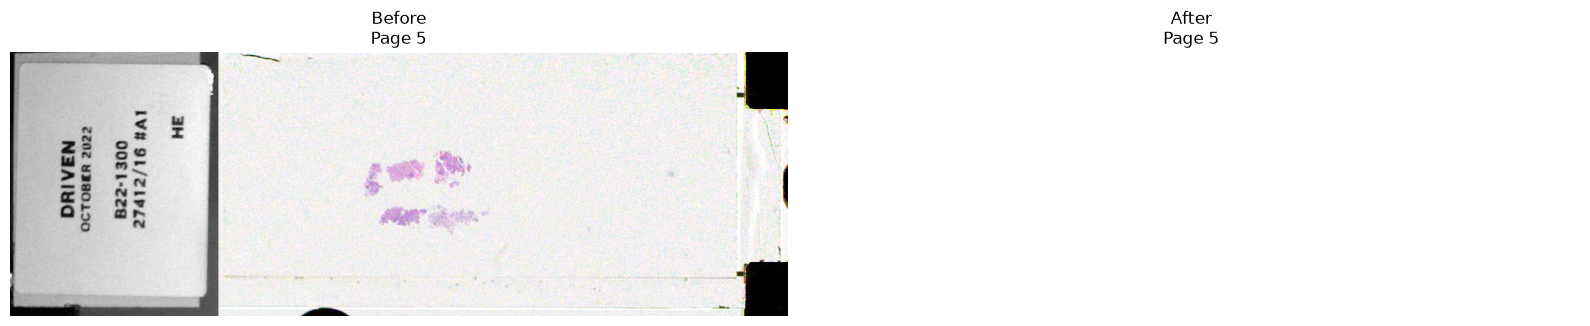

In [ ]:
source = image_path
source_info = inspect_slide(source)
source_label = find_label_page(source_info)

with tifffile.TiffFile(source) as slide:
    before = slide.pages[source_label.index].asarray()

with TemporaryDirectory() as directory:
    output = Path(directory) / source.name

    result = remove_label(
        source,
        mode="copy",
        output=output,
    )

    with tifffile.TiffFile(output) as slide:
        after = slide.pages[result.label_page].asarray()

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(16, 5),
    )

    axes[0].imshow(before)
    axes[0].set_title(f"Before\nPage {source_label.index}")
    axes[0].axis("off")

    axes[1].imshow(after)
    axes[1].set_title(f"After\nPage {result.label_page}")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
# | hide
import nbdev

nbdev.nbdev_export()